In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

In [173]:
df = pd.read_csv('penguins.csv')

In [174]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    str    
dtypes: float64(4), str(1)
memory usage: 13.6 KB


In [175]:
df.drop_duplicates(inplace=True)
df = df.dropna()

In [176]:
df['sex'].value_counts()

sex
MALE      169
FEMALE    165
.           1
Name: count, dtype: int64

In [177]:
df = df[df['sex'] != '.']
df['sex'] = df['sex'].map({'MALE':0, 'FEMALE':1})

In [178]:
def normalisasi(data):
    X = data.values

    min = np.min(X, axis=0)
    max = np.max(X, axis=0)
    
    scaled = (X - min) / (max - min + 1e-9)
    return scaled

In [179]:
def standarisasi(data):
    X = data.values

    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    std[std == 0] = 1

    scaled = (X - mean) / std
    return scaled

In [180]:
df_scaled = (df - df.mean(axis=0)) / (df.std(axis=0) + 1e-9)

In [181]:
def kmean(data, k, p=2, iteration=100, epsilon=1e-4):
    np.random.seed(42)
    X = data.values
    random_idx = np.random.choice(len(X), k, replace=False)
    centroid = X[random_idx]

    for i in range(iteration):
        # ngitung selisih fitur per centroid
        diff = np.abs(X[:, np.newaxis] - centroid)

        # minkowski
        distance = np.sum(diff**p, axis=2)**(1/p)

        # letak centroid tiap value
        label = np.argmin(distance, axis=1)

        # update centroid
        # new_centroid = np.array([X[label == i].mean(axis=0) for i in range(k)])
        new_centroid = np.array([X[label == i].mean(axis=0) for i in range(k)])        
        if np.linalg.norm(new_centroid - centroid) < epsilon:
            break

        centroid = new_centroid
    return label, centroid

In [182]:
def wcss(data, k, p=2):
    cluster, centroid = kmean(df_scaled, k, p=2)
    X = data.values

    diff = np.abs(X[:, np.newaxis] - centroid) 
    distance = np.sum(diff**p, axis=2)**(1/p)

    min_distance = np.min(distance, axis=1)

    if p ==2:
        error = np.sum(min_distance ** 2)
    else:
        error = np.sum(min_distance)

    return error  

In [183]:
hasil_wcss = wcss(df_scaled, k=3, p=2)
hasil_wcss

np.float64(834.6613290816191)

In [184]:
def elbow(data, max_k=10):
    wcss_value = []

    for k in range(1, max_k + 1):
        hasil_wcss = wcss(data, k)
        wcss_value.append(hasil_wcss)
    plt.plot(range(1, max_k + 1), wcss_value, marker='o', linestyle='--')
    plt.xticks(range(1, max_k + 1))
    plt.ylabel('wcss')
    plt.xlabel('Jumlah K')
    plt.grid(True)
    plt.show()

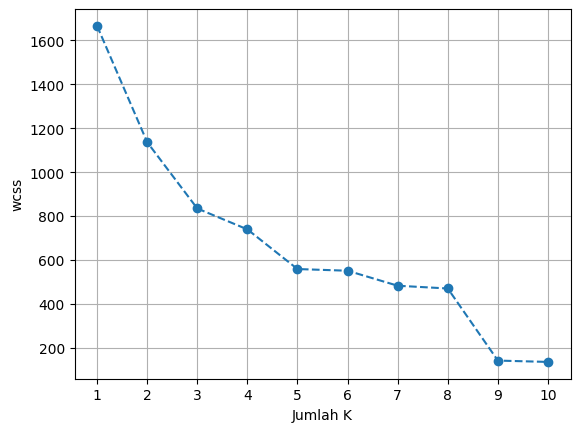

In [185]:
elbow(df_scaled, max_k=10)

In [186]:
def shilouette(data, k):
    cluster, centroid = kmean(data, k)
    score = []

    for i in range(len(data)):
        ci = cluster[i]

        samecp = data[cluster == ci].to_numpy()
        ai = np.mean(np.linalg.norm(samecp - data.iloc[i].to_numpy(), axis=1))

        distance_other = []
        for j in range(k):
            if j != ci:
                othercp = data[cluster == j].to_numpy()
                bi_temp = np.mean(np.linalg.norm(othercp - data.iloc[i].to_numpy(), axis=1))
                distance_other.append(bi_temp)
        bi = min(distance_other)
        
        score_i = (bi - ai) /  max(ai, bi)
        score.append(score_i)

    avrg_score = np.mean(score)
    return avrg_score

In [187]:
hasil_shilouette = shilouette(df_scaled, k=3)
hasil_shilouette

np.float64(0.4468484857408894)

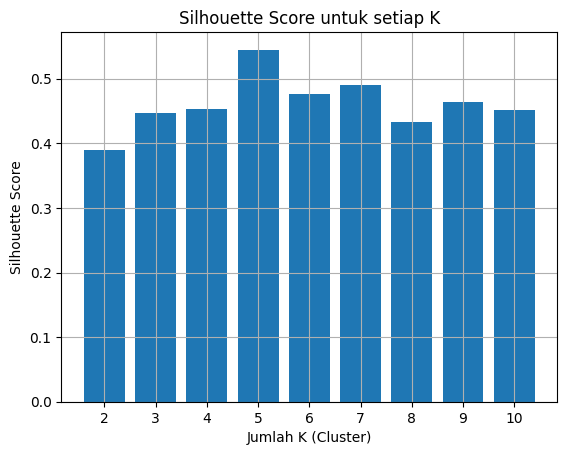

In [188]:

sscore = []
max_k = 10
for k in range(2,max_k+1):
    score = shilouette(df_scaled ,k)
    sscore.append(score)
plt.bar(range(2,max_k+1), sscore, )
plt.title(f"Silhouette Score untuk setiap K")
plt.xlabel('Jumlah K (Cluster)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
plt.show()

In [189]:
cluster, centroid = kmean(df_scaled, k=8)

df_scaled['cluster'] = cluster
df_scaled.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,cluster
0,-0.894771,0.773357,-0.126484,-0.568632,-0.986615,0
1,-0.821531,0.114555,-0.107519,-0.506444,1.010532,4
2,-0.675053,0.418617,-0.073383,-1.190516,1.010532,4
4,-1.334207,1.077420,-0.080969,-0.941762,1.010532,2
5,-0.858151,1.736222,-0.092348,-0.693009,-0.986615,0


In [190]:
import numpy as np

# Contoh Data: Titik A (Data) dan Titik B (Centroid)
# Anggap ini data dengan 5 fitur
titik_a = np.array([1, 5, 2, 8, 4])
titik_b = np.array([2, 4, 5, 1, 3])

# ---------------------------------------------------------
# 1. JARAK MANHATTAN (Minkowski p=1)
# Rumus: Jumlah selisih mutlak
# ---------------------------------------------------------
def hitung_manhattan(a, b):
    # |x1 - x2| + |y1 - y2| + ...
    jarak = np.sum(np.abs(a - b))
    return jarak

# ---------------------------------------------------------
# 2. JARAK EUCLIDEAN (Minkowski p=2)
# Rumus: Akar dari jumlah kuadrat selisih
# ---------------------------------------------------------
def hitung_euclidean(a, b):
    # sqrt((x1-x2)^2 + (y1-y2)^2 + ...)
    jarak = np.sqrt(np.sum((a - b)**2))
    return jarak

# ---------------------------------------------------------
# 3. JARAK CHEBYSHEV (Minkowski p=Infinity)
# Rumus: Nilai selisih mutlak yang paling besar (Max)
# ---------------------------------------------------------
def hitung_chebyshev(a, b):
    # max(|x1 - x2|, |y1 - y2|, ...)
    jarak = np.max(np.abs(a - b))
    return jarak

# ---------------------------------------------------------
# OPSI TAMBAHAN: FUNGSI MINKOWSKI GENERAL
# Bisa atur p sesuka hati
# ---------------------------------------------------------
def hitung_minkowski_general(a, b, p):
    # Rumus umum Minkowski
    if np.isinf(p):
        return np.max(np.abs(a -b))
    else:
        return np.sum(np.abs(a - b)**p)**(1/p)

# --- TES HASILNYA ---
print(f"Data A: {titik_a}")
print(f"Data B: {titik_b}")
print("-" * 30)
print(f"Jarak Manhattan (p=1)  : {hitung_manhattan(titik_a, titik_b)}")
print(f"Jarak Euclidean (p=2)  : {hitung_euclidean(titik_a, titik_b)}")
print(f"Jarak Chebyshev (p=inf): {hitung_chebyshev(titik_a, titik_b)}")

# Cek validasi pakai rumus general
print("-" * 30)
print(f"Validasi Minkowski p=1 : {hitung_minkowski_general(titik_a, titik_b, 1)}")
print(f"Validasi Minkowski p=2 : {hitung_minkowski_general(titik_a, titik_b, 2)}")
print(f"Validasi Minkowski p=inf : {hitung_minkowski_general(titik_a, titik_b, float('inf'))}")

Data A: [1 5 2 8 4]
Data B: [2 4 5 1 3]
------------------------------
Jarak Manhattan (p=1)  : 13
Jarak Euclidean (p=2)  : 7.810249675906654
Jarak Chebyshev (p=inf): 7
------------------------------
Validasi Minkowski p=1 : 13.0
Validasi Minkowski p=2 : 7.810249675906654
Validasi Minkowski p=inf : 7
